# Titanic Survival Analysis

## Project Overview

This project analyzes the Titanic dataset to identify the key factors that influenced passenger survival. Using Python and data analysis techniques, we explore patterns related to demographics, socio-economic status, and travel details.


## Objective

The main objective of this project is to:

* Understand the dataset and perform data cleaning
* Analyze survival patterns among passengers
* Identify key factors affecting survival
* Generate meaningful insights using data analysis


## Dataset Information

The dataset contains information about passengers aboard the Titanic, including:

* Passenger details (Age, Sex)
* Ticket class (Pclass)
* Fare paid
* Number of siblings/spouses (SibSp)
* Number of parents/children (Parch)
* Embarked port
* Survival status (Target variable)


## Key Questions

During this analysis, I aim to answer:

1. What factors influenced survival?
2. Did gender affect survival rate?
3. Did passenger class impact survival?
4. Is there any relationship between fare and survival?
5. Did age play a role in survival?


# Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'D:\DATA_ANALYSIS\project\titanic_data_analysis\data\data.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Data understanding

In [2]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


(891, 12)

In [3]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Data Cleaning

In [5]:
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df = df.drop('Cabin', axis=1)

df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

### Why?
1. Age is numerical type data to handle skewness and outliers we use median
2. Embarked is categorial type data because we cant calculate text data
3. Cabin had high missing values > 70% that why i dropped entirely column 

# Feature Engineering

In [6]:
df['FamilySize'] = df['SibSp'] + df['Parch']
df['IsAlone'] = (df['FamilySize'] == 0).astype(int)

Feature engineering main maine raw data se meaningfull variable banaya hu. jaise abhi model  ko sirf 1 column se family size pattern samj aayegi instead of 2 separate column se 

# EDA

1. Survival Count

In [7]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

2. Gender-wise Survival

In [8]:
df.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

3. Class Analysis

In [9]:
df.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

4. Age Analysis

In [10]:
df.groupby('Survived')['Age'].mean()

Survived
0    30.415100
1    28.549778
Name: Age, dtype: float64

5. Fare Analysis

In [11]:
df.groupby('Pclass')['Fare'].mean()

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64

# Visualizations


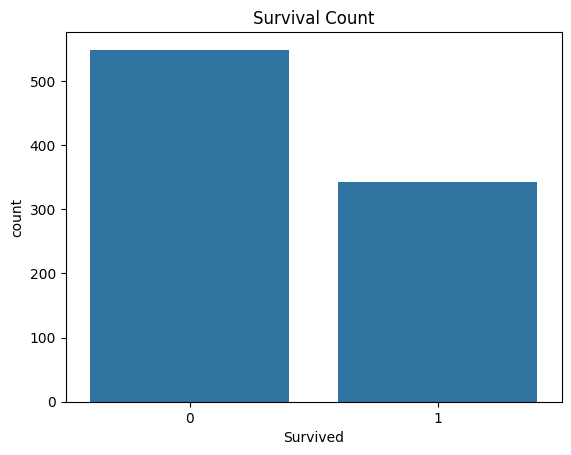

In [12]:
sns.countplot(x='Survived', data=df)
plt.title('Survival Count')
plt.savefig(r'D:\DATA_ANALYSIS\project\titanic_data_analysis\charts\survival_count.png')
plt.show()

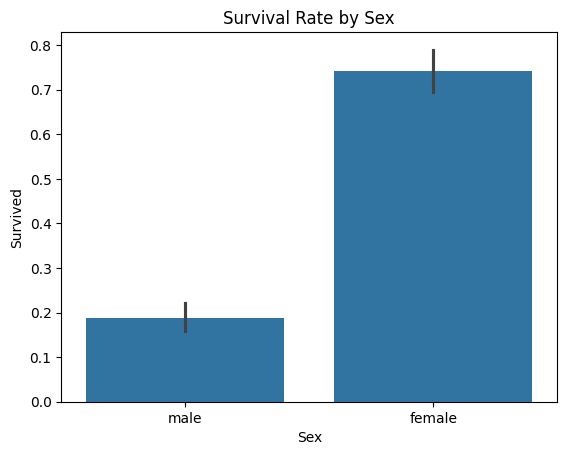

In [13]:
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Survival Rate by Sex')
plt.savefig(r'D:\DATA_ANALYSIS\project\titanic_data_analysis\charts\survival_by_sex.png')
plt.show()

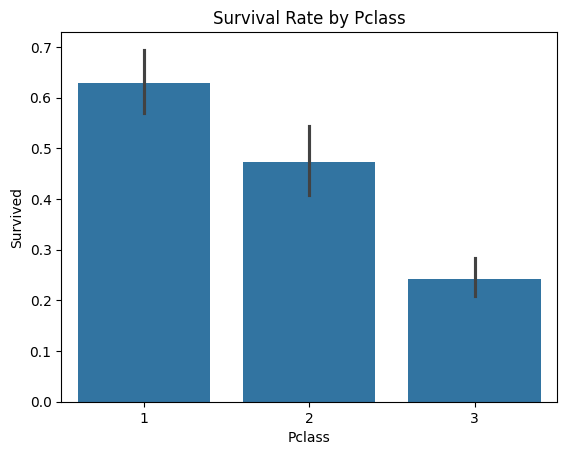

In [14]:
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival Rate by Pclass')
plt.savefig(r'D:\DATA_ANALYSIS\project\titanic_data_analysis\charts\survival_by_pclass.png')
plt.show()

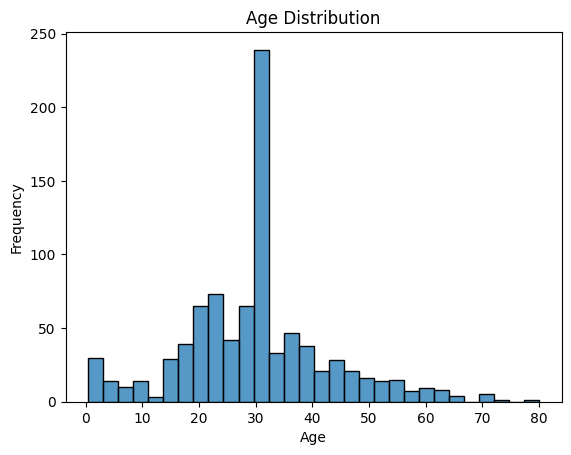

In [15]:
sns.histplot(df['Age'], bins=30)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.savefig(r'D:\DATA_ANALYSIS\project\titanic_data_analysis\charts\age_distribution.png')
plt.show()

# Key Insights

1. Females had significantly higher survival rate (74%) than males (19%)
2. First-Class passengers had highest survival chances (~63%)
3. Younger passengers (avg age 28) survived more than older (avg age 31)
4. High fare passengers had better survival access
5. Deaths (549) outnumbered survivals (342) - 62% mortality rate

# Conclusion

 
- Female + 1st Class = Highest survival (74%)
- Male + 3rd Class = Lowest survival (19%)
- "Women & Children First" policy data mein clearly visible!